<a id="0"></a> <br>
# Table of Contents

1. [Introduction to Tabular Playground Series - Nov 2021](#1)
    1. [Variable Describtions](#7)
1. [Load and Glance at the Data](#2)
1. [Missing Values](#3)
1. [Create a Validation Set](#4)
    1. [Remove target column](#5)
1. [Feature Scaling](#6)    
1. [First Model](#8)
    1. [Evaluation Metrics for Training set](#9)
    1. [Evaluation Metrics for Validation set](#10)
    1. [First Submission](#11)
1. [Selecting Models](#12)  
    1. [Helper Functions to Try New Models](#13) 
    1. [Split to the Small Data for Evaluating Models Fast](#14)
    1. [ML Models](#15)
    1. [XGBoost](#16)

<a id="1"></a> <br>
# 1. Introduction to Tabular Playground Series - Nov 2021 

TPS is a monthly competition prepared by Kaggle. The data is used for this competition is synthetic, but based on a real dataset and generated using a CTGAN. More information can be found on the [Competition Overview Page](https://www.kaggle.com/c/tabular-playground-series-nov-2021/overview).

**The goal** is **predicting probability** of the observed target 0 or 1. So it is **supervised learning** and **classification task**. Also **evaluation metric** is selected **area under the ROC curve**.

[back to the top](#0)

<a id="7"></a> <br>
## A. Variable Describtions:
- **df_train** : Pandas data frame for training data set
- **df_test** : Pandas data frame for test data set
- **x_all_train** : All training data
- **y_all_train** : All labels for training data


- **train_set** : Training Pandas data frame is splitted from training data set
- **val_set** : Validation Pandas data frame is splitted from training data set

#### Development Data Frames:
- **x_train** : Pandas data frame removed target columns from train_set
- **y_train** : List of targets from train_set
- **x_val** : Pandas data frame removed target columns from val_set
- **y_val** : List of targets from val_set
- **df_test_dev** : Standardized Pandas data frame for test data set

<a id="2"></a> <br>
# 2. Load and Glance at the Data
First things first, load and glance at the data.

[back to the top](#0)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [2]:
print('numpy version : ', np.__version__)
print('pandas version : ', pd.__version__)

numpy version :  1.19.5
pandas version :  1.3.4


In [3]:
df_train = pd.read_csv("/kaggle/input/tabular-playground-series-nov-2021/train.csv")
df_test = pd.read_csv("/kaggle/input/tabular-playground-series-nov-2021/test.csv")

In [4]:
df_train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,...,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,...,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,...,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,...,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,0
4,4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,...,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798,1


[back to the top](#0)

In [5]:
%%time
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Columns: 102 entries, id to target
dtypes: float64(100), int64(2)
memory usage: 466.9 MB
CPU times: user 10.1 ms, sys: 1.08 ms, total: 11.2 ms
Wall time: 16.2 ms


<font color=green>All variables is numerical. So we will not strive with categorical data.</font>

In [6]:
df_train.describe()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,...,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,0.306508,2.497590,306.644536,2.647901,0.177850,2.556832,2.699650,2.571593,2.538273,...,2.444471,0.155260,0.059407,0.144932,0.106419,2.547853,2.590159,0.158881,0.123048,0.506010
std,173205.225094,0.522450,1.554018,551.743893,1.544529,0.417488,1.562527,1.564000,1.549361,1.532988,...,1.542509,0.548397,0.119426,0.462015,0.209128,1.558427,1.525091,0.436190,0.264896,0.499964
min,0.000000,-3.797450,-1.223960,-1842.530000,-1.368560,-3.206210,-1.169770,-1.059310,-1.281970,-1.242020,...,-1.217700,-9.761770,-4.666240,-3.101500,-1.276540,-1.584740,-1.254730,-3.993500,-2.783380,0.000000
25%,149999.750000,0.026222,1.186238,43.573400,1.442028,0.019709,1.261038,1.385820,1.333848,1.292163,...,1.214178,0.018904,0.024483,0.017055,0.025461,1.247888,1.348078,0.013536,0.018105,0.000000
50%,299999.500000,0.097788,2.516500,133.626000,2.634130,0.061586,2.590425,2.801255,2.557985,2.475880,...,2.386845,0.068906,0.056649,0.063439,0.062151,2.601940,2.682090,0.058058,0.058471,1.000000
75%,449999.250000,0.397184,3.787630,302.262250,3.907640,0.112712,3.813662,3.996913,3.823450,3.804360,...,3.693872,0.125165,0.088162,0.113114,0.102016,3.820665,3.839520,0.110718,0.104872,1.000000
max,599999.000000,8.781500,6.226720,6119.280000,6.521150,8.265470,6.515070,6.586780,6.258770,6.389670,...,6.573890,18.412800,10.211800,8.623270,3.657220,6.254360,6.145300,10.767000,5.988110,1.000000


[back to the top](#0)

<a id="3"></a> <br>
# 3. Missing Values
Check missing values with several ways.

[back to the top](#0)

In [7]:
print(df_train.isnull().sum().shape)

(102,)


In [8]:
df_train.isnull().sum()

id        0
f0        0
f1        0
f2        0
f3        0
         ..
f96       0
f97       0
f98       0
f99       0
target    0
Length: 102, dtype: int64

In [9]:
df_train.isnull().sum().sum()

0

In [10]:
df_train.columns[df_train.isnull().any()]  # which columns has null value.

Index([], dtype='object')

There is no null value in training set.

[back to the top](#0)

In [11]:
missing_val_count_by_column = (df_train.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0])

Series([], dtype: int64)


We knew there is any null value, just use the way.

[back to the top](#0)

In [12]:
missing_val_count_by_column_for_test = (df_test.isnull().sum())
print(missing_val_count_by_column_for_test[missing_val_count_by_column > 0])

Series([], dtype: int64)


There is no null data in test set. 

[Variable Describtions](#7)

<a id="4"></a> <br>
# 4. Create a Validation Set
Before go any further, I will create a validation set from train data frame. We don't know what it represents in real life as it was created using CTGAN, so I'll split it randomly.

[back to the top](#0)

In [13]:
from sklearn.model_selection import train_test_split

random_state=42
test_size = 0.2

train_set, val_set = train_test_split(df_train, test_size = test_size, random_state=random_state)

In [14]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 480000 entries, 501294 to 121958
Columns: 102 entries, id to target
dtypes: float64(100), int64(2)
memory usage: 377.2 MB


In [15]:
train_set.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
501294,501294,-0.003734,2.556160,84.4223,1.11431,0.100421,1.880790,1.01261,1.018440,0.291871,...,3.49973,0.100869,0.111332,0.096777,0.104308,4.01259,3.939720,0.075329,0.007768,0
285039,285039,0.030401,3.141980,1505.2500,3.83578,0.108713,3.368640,2.63339,0.781402,2.452450,...,4.00255,0.065180,0.075172,0.068678,0.085737,3.04683,3.306850,0.011034,0.004364,0
47556,47556,2.353360,0.302355,178.2610,4.35292,0.033108,-0.073121,4.11263,0.442284,0.621988,...,3.99828,0.086291,0.101886,-0.057256,0.046584,2.82712,1.121930,-0.007859,0.122603,1
580653,580653,0.088604,2.633210,193.9350,4.85363,0.101375,2.883940,2.74406,5.543720,1.389560,...,4.47503,0.164190,0.089708,0.024681,0.052392,2.15871,3.796730,0.140890,-0.161706,0
547794,547794,0.720623,3.643570,61.5013,3.96251,0.074336,2.471030,2.40652,1.871790,5.407090,...,0.15999,0.022028,0.037424,-0.167684,-0.013729,5.02997,0.560307,0.008065,-0.056925,1


<a id="5"></a> <br>
## A. Remove Target Column
Remove target and id columns from train_set and make x_train data frame and make y_train list.

[back to the top](#0)

[back to the top](#0)

In [16]:
# x_train = train_set.drop(labels = ["id","target"], axis=1)
x_train = train_set.drop(labels = "target", axis=1)
y_train = train_set["target"].values

# validation set
x_val = val_set.drop(labels = "target", axis=1)
y_val = val_set["target"].values

# development test set
df_test_dev = df_test.copy()

[Variable Describtions](#7)

[back to the top](#0)

In [17]:
x_train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
501294,501294,-0.003734,2.556160,84.4223,1.11431,0.100421,1.880790,1.01261,1.018440,0.291871,...,-0.010272,3.49973,0.100869,0.111332,0.096777,0.104308,4.01259,3.939720,0.075329,0.007768
285039,285039,0.030401,3.141980,1505.2500,3.83578,0.108713,3.368640,2.63339,0.781402,2.452450,...,0.061370,4.00255,0.065180,0.075172,0.068678,0.085737,3.04683,3.306850,0.011034,0.004364
47556,47556,2.353360,0.302355,178.2610,4.35292,0.033108,-0.073121,4.11263,0.442284,0.621988,...,0.048097,3.99828,0.086291,0.101886,-0.057256,0.046584,2.82712,1.121930,-0.007859,0.122603
580653,580653,0.088604,2.633210,193.9350,4.85363,0.101375,2.883940,2.74406,5.543720,1.389560,...,0.086745,4.47503,0.164190,0.089708,0.024681,0.052392,2.15871,3.796730,0.140890,-0.161706
547794,547794,0.720623,3.643570,61.5013,3.96251,0.074336,2.471030,2.40652,1.871790,5.407090,...,0.021995,0.15999,0.022028,0.037424,-0.167684,-0.013729,5.02997,0.560307,0.008065,-0.056925


In [18]:
x_val.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
4242,4242,0.572142,0.45796,1058.4500,2.364920,0.007477,0.820831,1.675160,1.863390,3.483510,...,0.115815,4.95683,0.126923,0.027469,0.043016,0.134055,0.979234,3.692340,0.087287,0.098037
60608,60608,-0.032470,1.56156,-81.8397,0.930626,0.082330,2.946920,4.699320,3.226460,0.558439,...,0.063842,3.68247,0.112949,0.037217,0.069304,0.052769,4.608660,3.899140,0.000146,0.925255
392832,392832,0.870197,3.06120,130.3060,1.688390,2.128780,3.021610,1.672580,0.457961,0.414155,...,0.008822,2.87189,0.095940,0.135351,0.076317,-0.033720,3.286110,0.686642,0.036057,0.079040
41643,41643,0.039961,2.60849,42.8086,1.255420,0.047619,4.679990,4.532300,3.523930,1.920310,...,0.079432,2.04093,-0.006406,0.059488,-0.029460,0.091797,0.985057,4.921910,0.094134,0.038149
464234,464234,0.108420,3.74958,66.9359,2.442530,0.010796,-0.032664,0.912627,4.841340,0.480072,...,0.046212,1.10374,0.084090,-0.022667,0.039098,0.050707,2.588800,4.285320,0.001471,-0.021102


In [19]:
print(y_train[0:5])
print(y_val[0:5])

[0 0 1 0 1]
[0 0 1 0 1]


<a id="6"></a> <br>
# 5. Feature Scaling
In order to, ML algorithms perform well, I will scale data with Standardization method.

[Variable Describtions](#7)

[back to the top](#0)

In [20]:
columns = x_train.columns[1:]  # we get all columns except index.
print(columns)

Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10',
       'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20',
       'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30',
       'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40',
       'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50',
       'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60',
       'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70',
       'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80',
       'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90',
       'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99'],
      dtype='object')


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

[Variable Describtions](#7)

[back to the top](#0)

In [22]:
x_train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
501294,501294,-0.003734,2.556160,84.4223,1.11431,0.100421,1.880790,1.01261,1.018440,0.291871,...,-0.010272,3.49973,0.100869,0.111332,0.096777,0.104308,4.01259,3.939720,0.075329,0.007768
285039,285039,0.030401,3.141980,1505.2500,3.83578,0.108713,3.368640,2.63339,0.781402,2.452450,...,0.061370,4.00255,0.065180,0.075172,0.068678,0.085737,3.04683,3.306850,0.011034,0.004364
47556,47556,2.353360,0.302355,178.2610,4.35292,0.033108,-0.073121,4.11263,0.442284,0.621988,...,0.048097,3.99828,0.086291,0.101886,-0.057256,0.046584,2.82712,1.121930,-0.007859,0.122603
580653,580653,0.088604,2.633210,193.9350,4.85363,0.101375,2.883940,2.74406,5.543720,1.389560,...,0.086745,4.47503,0.164190,0.089708,0.024681,0.052392,2.15871,3.796730,0.140890,-0.161706
547794,547794,0.720623,3.643570,61.5013,3.96251,0.074336,2.471030,2.40652,1.871790,5.407090,...,0.021995,0.15999,0.022028,0.037424,-0.167684,-0.013729,5.02997,0.560307,0.008065,-0.056925


In [23]:
x_val.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
4242,4242,0.572142,0.45796,1058.4500,2.364920,0.007477,0.820831,1.675160,1.863390,3.483510,...,0.115815,4.95683,0.126923,0.027469,0.043016,0.134055,0.979234,3.692340,0.087287,0.098037
60608,60608,-0.032470,1.56156,-81.8397,0.930626,0.082330,2.946920,4.699320,3.226460,0.558439,...,0.063842,3.68247,0.112949,0.037217,0.069304,0.052769,4.608660,3.899140,0.000146,0.925255
392832,392832,0.870197,3.06120,130.3060,1.688390,2.128780,3.021610,1.672580,0.457961,0.414155,...,0.008822,2.87189,0.095940,0.135351,0.076317,-0.033720,3.286110,0.686642,0.036057,0.079040
41643,41643,0.039961,2.60849,42.8086,1.255420,0.047619,4.679990,4.532300,3.523930,1.920310,...,0.079432,2.04093,-0.006406,0.059488,-0.029460,0.091797,0.985057,4.921910,0.094134,0.038149
464234,464234,0.108420,3.74958,66.9359,2.442530,0.010796,-0.032664,0.912627,4.841340,0.480072,...,0.046212,1.10374,0.084090,-0.022667,0.039098,0.050707,2.588800,4.285320,0.001471,-0.021102


In [24]:
df_test_dev.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
0,600000,0.003229,4.838660,585.529,2.282910,0.713180,3.907830,0.480696,1.482270,4.891810,...,0.112910,1.073550,0.122149,0.086330,0.036010,0.010619,0.290343,1.898200,0.131533,0.012047
1,600001,0.008602,0.505536,-100.099,3.012670,0.027199,1.194610,5.036620,2.517440,4.553890,...,-0.020214,2.622340,0.123307,0.033063,0.123059,0.005771,-0.392923,3.689640,0.047418,0.120015
2,600002,1.461000,2.437260,-112.964,3.541230,0.752338,4.338310,1.648080,4.699910,1.950250,...,-0.011036,2.030180,-0.000426,0.084091,0.123605,0.499554,4.054650,3.330670,0.108843,0.064687
3,600003,0.140556,3.085610,179.451,0.573945,0.057342,2.216790,1.623480,0.526174,1.542540,...,0.050117,0.221613,0.045298,0.129966,0.004015,0.018279,2.696580,-0.533491,0.052524,0.011058
4,600004,0.128876,5.199760,107.466,-0.497149,0.080220,0.458121,0.629839,5.240460,-0.232279,...,0.058860,2.660430,0.135425,0.036481,0.093912,0.056315,1.110710,3.584470,0.145319,-0.050393


In [25]:
print(x_train.shape)

(480000, 101)


In [26]:
std_scaler = StandardScaler()

**x_train is still contained id column!**

In [27]:
# v1 method
# x_train[columns] = std_scaler.fit_transform(x_train[columns])
# x_val[columns] = std_scaler.transform(x_val[columns])

# df_test_dev[columns] = std_scaler.transform(df_test_dev[columns])

## Create a Pipeline for Preparing Data to Training

In [28]:
num_pipeline = Pipeline([(('std_scaler'), StandardScaler()),])
full_pipeline = ColumnTransformer([('num', num_pipeline, columns),])

x_train[columns] = full_pipeline.fit_transform(x_train)
x_val[columns] = full_pipeline.transform(x_val)
df_test_dev[columns] = full_pipeline.transform(df_test_dev)

[Variable Describtions](#7)

[back to the top](#0)

In [29]:
# x_train.shape
x_train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
501294,501294,-0.594503,0.038545,-0.402755,-0.992660,-0.185420,-0.433030,-1.078872,-1.001010,-1.466545,...,-0.722223,0.683647,-0.099393,0.422351,-0.104106,-0.009458,0.940028,0.884119,-0.191837,-0.435919
285039,285039,-0.529087,0.415540,2.180473,0.769118,-0.165539,0.519040,-0.042561,-1.154047,-0.056276,...,-0.088348,1.009493,-0.164918,0.127465,-0.164721,-0.098455,0.320288,0.469112,-0.339382,-0.448777
47556,47556,3.922707,-1.411853,-0.232146,1.103895,-0.346808,-1.683332,0.903250,-1.372990,-1.251069,...,-0.205787,1.006726,-0.126157,0.345318,-0.436386,-0.286084,0.179297,-0.963659,-0.382738,-0.002155
580653,580653,-0.417544,0.088130,-0.203648,1.428036,-0.183133,0.208882,0.028200,1.920623,-0.750054,...,0.136159,1.315678,0.016862,0.246006,-0.259632,-0.258250,-0.249629,0.790353,-0.041385,-1.076073
547794,547794,0.793677,0.738330,-0.444428,0.851158,-0.247960,-0.055338,-0.187620,-0.450066,1.872299,...,-0.436728,-1.480628,-0.244143,-0.180377,-0.674600,-0.575119,1.592892,-1.331945,-0.346197,-0.680284


In [30]:
x_val.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
4242,4242,0.509124,-1.311716,1.368139,-0.183062,-0.408260,-1.111295,-0.655244,-0.455489,0.616725,...,0.393367,1.627902,-0.051559,-0.261560,-0.220079,0.133096,-1.006513,0.721899,-0.164395,-0.094949
60608,60608,-0.649574,-0.601513,-0.705039,-1.111570,-0.228794,0.249183,1.278374,0.424543,-1.292549,...,-0.066479,0.802069,-0.077215,-0.182062,-0.163371,-0.256447,1.322533,0.857509,-0.364369,3.029696
392832,392832,1.080326,0.363555,-0.319333,-0.621022,4.677716,0.296977,-0.656893,-1.362869,-1.386727,...,-0.553277,0.276783,-0.108443,0.618228,-0.148242,-0.670921,0.473837,-1.249101,-0.281960,-0.166703
41643,41643,-0.510766,0.072221,-0.478414,-0.901310,-0.312018,1.358169,1.171583,0.616597,-0.403619,...,0.071458,-0.261710,-0.296346,-0.000440,-0.376425,-0.069415,-1.002776,1.528195,-0.148682,-0.321162
464234,464234,-0.379568,0.806551,-0.434547,-0.132820,-0.400302,-1.657444,-1.142800,1.467149,-1.343702,...,-0.222465,-0.869043,-0.130198,-0.670421,-0.228530,-0.266327,0.026365,1.110748,-0.361329,-0.544970


In [31]:
df_test_dev.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
0,600000,-0.581160,1.507410,0.508314,-0.236152,1.283714,0.864066,-1.418972,-0.701550,1.535961,...,0.367664,-0.888608,-0.060324,0.218461,-0.235192,-0.458435,-1.448582,-0.454616,-0.062858,-0.419756
1,600001,-0.570863,-1.281099,-0.738236,0.236268,-0.360974,-0.872115,1.494040,-0.033218,1.315392,...,-0.810188,0.115066,-0.058198,-0.215942,-0.047411,-0.481670,-1.887042,0.720128,-0.255888,-0.011930
2,600002,2.212560,-0.037971,-0.761626,0.578438,1.377598,1.139529,-0.672558,1.375839,-0.384076,...,-0.728979,-0.268676,-0.285368,0.200202,-0.046233,1.884650,0.967018,0.484732,-0.114928,-0.220921
3,600003,-0.317982,0.379264,-0.229982,-1.342472,-0.288704,-0.218025,-0.688287,-1.318829,-0.650199,...,-0.187916,-1.440694,-0.201419,0.574313,-0.304211,-0.421729,0.095528,-2.049208,-0.244170,-0.423492
4,600004,-0.340366,1.739790,-0.360859,-2.035858,-0.233853,-1.343392,-1.323612,1.724831,-1.808673,...,-0.110557,0.139750,-0.035950,-0.188065,-0.110287,-0.239453,-0.922143,0.651163,-0.031221,-0.655609


[Variable Describtions](#7)

[back to the top](#0)

In [32]:
print(len(list(df_test_dev)))
print(list(df_test_dev))

101
['id', 'f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80', 'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90', 'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99']


In [33]:
# assert False

<a id="8"></a> <br>
# 6. First Model and Submit
I will apply simple ML models first and submit to the competition.

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
%%time
lin_reg = LogisticRegression()
lin_reg.fit(x_train[columns], y_train)
y_train_head = lin_reg.predict(x_train[columns])

CPU times: user 2.07 s, sys: 559 ms, total: 2.63 s
Wall time: 1.52 s


In [36]:
(y_train_head<1).any()

True

In [37]:
(y_train_head==0).sum().sum()

234314

[Variable Describtions](#7)

[back to the top](#0)

<a id="9"></a> <br>
## A. Evaluation Metrics for Training set

In [38]:
# firts evaluation
print(lin_reg.score(x_train[columns], y_train))

0.7375520833333333


In [39]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [40]:
fpr, tpr, thresholds = roc_curve(y_train, y_train_head)
roc_auc_score_train = roc_auc_score(y_train, y_train_head)
print("ROC AUC Score:",roc_auc_score_train)

ROC AUC Score: 0.7374481949002129


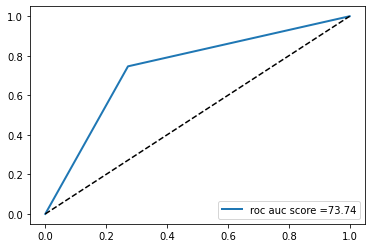

In [41]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal3
    plt.legend(loc = 'lower right')
    plt.show()
    
plot_roc_curve(fpr, tpr, label=("roc auc score ="+str(round(roc_auc_score_train*100,2))))

In [42]:
print("ROC AUC Score:",roc_auc_score(y_train, y_train_head))

ROC AUC Score: 0.7374481949002129


### Probability of Predictions

In [43]:
# Before ROC AUC Score
y_train_prob_head = lin_reg.predict_proba(x_train[columns])
print(y_train_prob_head.shape)
y_train_prob_head[0,:]

(480000, 2)


array([0.65573359, 0.34426641])

In [44]:
y_train_prob_head = lin_reg.predict_proba(x_train[columns])[:,1] # score = proba of positive
roc_auc_score_train_prob = roc_auc_score(y_train, y_train_prob_head)
print("ROC AUC Score of probability:", roc_auc_score_train_prob)

ROC AUC Score of probability: 0.7488677149101655


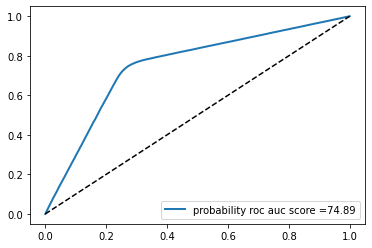

In [45]:
fpr_prob, tpr_prob, thresholds_prob = roc_curve(y_train, y_train_prob_head)
plot_roc_curve(fpr_prob, tpr_prob, label=("probability roc auc score ="+str(round(roc_auc_score_train_prob*100,2))))

**This metrics are just for training data. Now I will evaluate model on validation data with predicted probability.**

[back to the top](#0)

<a id="10"></a> <br>
## B. Evaluation Metrics for Validation set

In [46]:
y_val_prob_head = lin_reg.predict_proba(x_val[columns])[:,1] # score = proba of positive
roc_auc_score_val_prob = roc_auc_score(y_val, y_val_prob_head)
print("ROC AUC Score of probability:", roc_auc_score_val_prob)

ROC AUC Score of probability: 0.7506636452348747


In [47]:
first_preds = lin_reg.predict_proba(df_test_dev[columns])[:,1]

In [48]:
first_preds

array([0.67858001, 0.61894793, 0.79012422, ..., 0.52080279, 0.6430341 ,
       0.6564326 ])

<a id="11"></a> <br>
## C. First Submission
[back to the top](#0)

In [49]:
sub = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv')

In [50]:
sub['target']=first_preds
sub.to_csv('submission.csv', index=False)

In [51]:
sub

,id,target
0,600000,0.678580
1,600001,0.618948
2,600002,0.790124
3,600003,0.472950
4,600004,0.551522
...,...,...
539995,1139995,0.656580
539996,1139996,0.646020
539997,1139997,0.520803
539998,1139998,0.643034


<a id="12"></a> <br>
# 7. Selecting Models
[back to the top](#0)

In [52]:
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


<a id="13"></a> <br>
## A. Helper Functions to Try New Models
[back to the top](#0)

In [53]:
def plot_roc_curve(fpr, tpr, label=None, title=None):
    """
    """
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal3
    plt.legend(loc = 'lower right')
    plt.title(title)
    plt.show()

    
def roc_auc_score_func(y_true, y_head, plot_roc=False):
    """ evaluate roc auc score
    Args:
        y_true : a numpy array. True labels.
        y_head : a numpy array. Predicted labels.
        plot_roc : if you want to plot roc curve. (Default is False)
        
    """
    
    if plot_roc:
        fpr, tpr, thresholds = roc_curve(y_true, y_head)
        plot_roc_curve(fpr, tpr, label=None, title=None)
        
        
    # evaluate roc auc score
    model_roc_auc_score = roc_auc_score(y_true, y_true)
#     print("ROC AUC Score:",roc_auc_score_train)
    
    return model_roc_auc_score


def train_model_w_kfold(clf, X, y, n_splits=5):
    """train ml models with kfold and return auc score for probability
    
    Args:
        clf : model classifier
        X : a numpy.darray training data 
        y : a numpy.darray training labels
        n_splits : number of Kfold splits
        
    Returns:
        
    """
    roc_auc_score_list = []  # roc auc score list
    acc_score_list = [] # auc score list
    
    skf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
    
    print("Model:", clf)
    
    for i, (train_index, val_index) in enumerate(skf.split(X, y)):
        print("Fitting fold", i+1)
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        
        # TRAINING
        training_start_time = time.time()
        
#         model = LogisticRegression(solver='liblinear')
        model = clf
        model.fit(X_train, y_train)
        
        training_end_time = time.time()
        training_time = training_end_time - training_start_time
        print(f"fold {i+1} elapsed seconds: {training_time}")
        
        
        # EVALUATING
        evaluating_start_time = time.time()
        
        roc_auc_score_list.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        acc_score_list.append(accuracy_score(y_val, model.predict(X_val)))
        
        evaluating_end_time = time.time()
        evaluating_time = evaluating_end_time - evaluating_start_time
        print(f"fold {i+1} evaluating scores elapsed seconds: {evaluating_time}")
    
    
        print(f"fold: {i+1}, accuracy: {round(acc_score_list[i]*100,3)}, auc: {round(roc_auc_score_list[i]*100,3)}")

        
    roc_auc_score_mean = np.mean(roc_auc_score_list)
    accuracy_mean = np.mean(acc_score_list)    
    
    return roc_auc_score_mean, accuracy_mean

[back to the top](#0)

In [54]:
# assert False

<a id="14"></a> <br>
## B. Split to the Small Data for Evaluating Models Fast
[back to the top](#0)

In [55]:
df_train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,...,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,...,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,...,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,...,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,0
4,4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,...,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798,1


In [56]:
df_train.shape

(600000, 102)

In [57]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.05, random_state=42)

for train_index, test_index in split.split(df_train, df_train["target"]):
#     strat_dev_set = housing.loc[train_index]
#     strat_test_set = housing.loc[test_index]
    strat_dev_set = df_train.loc[test_index]
    
    
print(strat_dev_set.shape)

(30000, 102)


In [58]:
strat_dev_set.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
500508,500508,-0.017256,5.40012,-82.5693,1.50875,0.022105,3.763450,4.86259,0.414386,4.082520,...,5.412670,0.101710,0.120630,0.076717,0.144659,3.01341,2.07637,-0.007831,0.083423,0
13024,13024,0.527068,1.51759,-44.3496,4.16608,-0.037180,3.739150,2.86214,-0.050160,4.716540,...,1.051330,1.074210,0.093031,0.050078,0.158812,2.26220,3.80917,1.838590,0.041594,0
7711,7711,0.056056,4.48045,-123.1970,4.52480,0.039227,0.412068,3.06953,3.046160,3.651430,...,4.546180,0.019740,0.029191,1.127980,0.009161,3.68678,5.40692,0.093436,0.041143,0
458014,458014,0.005352,4.86801,64.7466,3.44409,0.077747,2.292660,3.62764,2.758190,0.355848,...,4.457370,-0.049807,0.078192,-0.043896,0.031518,5.67668,4.46138,0.062389,0.065177,0
237818,237818,0.020472,1.17971,540.4740,4.77031,0.089836,1.068130,1.58734,2.328010,0.928818,...,0.191045,0.022673,0.142360,0.011062,0.058394,3.86785,3.77751,-0.003097,0.112678,1


In [59]:
(strat_dev_set["target"]==1).sum()

15180

In [60]:
# assert False

<a id="15"></a> <br>
## C. ML Models
[back to the top](#0)

In [61]:
!pip install --upgrade xgboost

# # xgb.__version__

     |████████████████████████████████| 173.5 MB 11 kB/s 
  Attempting uninstall: xgboost
    Found existing installation: xgboost 1.5.0
    Uninstalling xgboost-1.5.0:
      Successfully uninstalled xgboost-1.5.0


In [62]:
from xgboost import XGBClassifier

In [63]:
xgb_clf = XGBClassifier(
    max_depth=8,
    learning_rate=0.01,
    n_estimators=10000,
    verbosity=1,
    silent=None,
    objective='binary:logistic',  
    tree_method = 'gpu_hist',
    booster='gbtree',
    n_jobs=-1,
    nthread=None,
    eval_metric='auc',
    gamma=0,
    min_child_weight=1,
    max_delta_step=0,
    subsample=0.7,
    colsample_bytree=1,
    colsample_bylevel=1,
    colsample_bynode=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    base_score=0.5,
    random_state=0,
    seed=None
)  # logistic regression for binary classification, output probability

[back to the top](#0)

In [64]:
target = strat_dev_set['target'].values
strat_dev_set = full_pipeline.fit_transform(strat_dev_set[columns])

In [65]:
%%time

import time


classifiers = [LogisticRegression(solver='liblinear', random_state = random_state),
               SVC(random_state = random_state, probability=True),
               DecisionTreeClassifier(random_state = random_state),
               RandomForestClassifier(random_state = random_state),
               KNeighborsClassifier(),
               xgb_clf]

# for SVC, predict_proba is not available when probability=False

clf_roc_auc_score_mean = [] 
clf_auc_score_mean = []

for clf in classifiers:
    
    start_time = time.time()
    
    roc_auc_score_mean, accuracy_mean = train_model_w_kfold(clf, X=strat_dev_set, y=target, n_splits=2)
    
    clf_roc_auc_score_mean.append(roc_auc_score_mean)
    clf_auc_score_mean.append(accuracy_mean)
    
    end_time = time.time()
    
    print('Elapsed seconds classifier training time:', end_time-start_time)

Model: LogisticRegression(random_state=42, solver='liblinear')
Fitting fold 1
fold 1 elapsed seconds: 0.07825398445129395
fold 1 evaluating scores elapsed seconds: 0.01765894889831543
fold: 1, accuracy: 71.247, auc: 73.735
Fitting fold 2
fold 2 elapsed seconds: 0.11303973197937012
fold 2 evaluating scores elapsed seconds: 0.016393184661865234
fold: 2, accuracy: 72.233, auc: 74.862
Elapsed seconds classifier training time: 0.26982951164245605
Model: SVC(probability=True, random_state=42)
Fitting fold 1
fold 1 elapsed seconds: 183.60260558128357
fold 1 evaluating scores elapsed seconds: 53.30770301818848
fold: 1, accuracy: 68.947, auc: 72.358
Fitting fold 2
fold 2 elapsed seconds: 183.95614194869995
fold 2 evaluating scores elapsed seconds: 54.732555627822876
fold: 2, accuracy: 69.313, auc: 73.092
Elapsed seconds classifier training time: 475.6370527744293
Model: DecisionTreeClassifier(random_state=42)
Fitting fold 1
fold 1 elapsed seconds: 2.446993827819824
fold 1 evaluating scores elap

/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


fold 1 elapsed seconds: 101.22214484214783
fold 1 evaluating scores elapsed seconds: 9.754634857177734
fold: 1, accuracy: 67.36, auc: 71.58
Fitting fold 2


/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


fold 2 elapsed seconds: 99.98673486709595
fold 2 evaluating scores elapsed seconds: 10.198700904846191
fold: 2, accuracy: 68.107, auc: 72.185
Elapsed seconds classifier training time: 221.19995832443237
CPU times: user 15min 9s, sys: 2.89 s, total: 15min 12s
Wall time: 14min 57s


[back to the top](#0)

In [66]:
clf_roc_auc_score_mean

[0.742987585767906,
 0.7272503551622544,
 0.5415859883823271,
 0.6849416271498652,
 0.5809291115698438,
 0.7188250663651122]

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


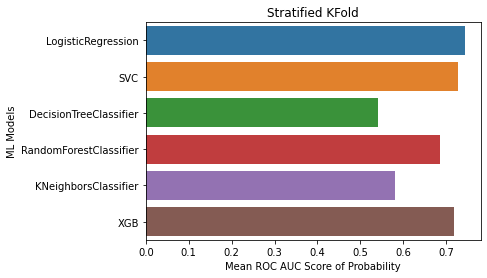

In [67]:
ML_Models = ["LogisticRegression",
             "SVC",
             "DecisionTreeClassifier",
             "RandomForestClassifier",
             "KNeighborsClassifier",
             "XGB"]

cv_results = pd.DataFrame({"clf_roc_auc_score_mean":clf_roc_auc_score_mean, 
                           "ML Models": ML_Models})

g = sns.barplot("clf_roc_auc_score_mean", "ML Models", data = cv_results)
g.set_xlabel("Mean ROC AUC Score of Probability")
g.set_title("Stratified KFold")
plt.show()

<a id="16"></a> <br>
## C. XGBoost
[back to the top](#0)

### XGB Training

In [68]:
%%time

xgb_clf = XGBClassifier(
    max_depth=8,
    learning_rate=0.01,
    n_estimators=10000,
    verbosity=1,
    silent=None,
    objective='binary:logistic',  
    tree_method = 'gpu_hist',
    booster='gbtree',
    n_jobs=-1,
    nthread=None,
    eval_metric='auc',
    gamma=0,
    min_child_weight=1,
    max_delta_step=0,
    subsample=0.7,
    colsample_bytree=1,
    colsample_bylevel=1,
    colsample_bynode=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    base_score=0.5,
    random_state=0,
    seed=random_state
)

xgb_clf.fit(x_train[columns], y_train)

/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


CPU times: user 4min 32s, sys: 2.51 s, total: 4min 34s
Wall time: 4min 34s


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='auc', gamma=0, gpu_id=0, importance_type=None,
              interaction_constraints='', learning_rate=0.01, max_delta_step=0,
              max_depth=8, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=10000, n_jobs=-1,
              nthread=2, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=42,
              silent=None, subsample=0.7, tree_method='gpu_hist', ...)

[back to the top](#0)

### XGB Evaluation

In [69]:
%%time
y_val_prob_head = xgb_clf.predict_proba(x_val[columns])[:,1] # score = proba of positive
roc_auc_score_val_prob = roc_auc_score(y_val, y_val_prob_head)

print("ROC AUC Score of probability:", roc_auc_score_val_prob)

ROC AUC Score of probability: 0.7456106602543537
CPU times: user 1min 30s, sys: 109 ms, total: 1min 30s
Wall time: 47.1 s


### Submission with XGB

In [70]:
xgb_preds = xgb_clf.predict_proba(df_test_dev[columns])[:,1]

In [71]:
sub = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv')
sub['target'] = xgb_preds
sub.to_csv('submission.csv', index=False)
sub

,id,target
0,600000,0.752434
1,600001,0.485740
2,600002,0.826051
3,600003,0.487778
4,600004,0.569572
...,...,...
539995,1139995,0.608709
539996,1139996,0.694782
539997,1139997,0.562111
539998,1139998,0.646196
